# Hypothesis Testing, Sampling Distributions, Standard Error & the CLT

**Goal:** Build real intuition for *why* hypothesis testing works — from first principles, with runnable code.

The whole thing works **only because of sampling distributions + standard error + the Central Limit Theorem (CLT)**.


### 🧭 The one idea that ties everything together

We'll return to this again and again:

> **If the null hypothesis were true, how surprising is our data? That surprise is the p-value.**

Every section in this notebook builds one piece of that sentence.

In [ ]:
# ── Setup ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# So our random numbers are reproducible
np.random.seed(42)

# Nicer plots
plt.rcParams.update({
    'figure.figsize': (9, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})

# We'll use this tiny utility later to convert z-scores to p-values.
# It's just the standard Normal CDF — nothing fancy.
normal_cdf = lambda x: 0.5 * (1 + math.erf(x / math.sqrt(2)))

normal_cdf(0)  # Example usage

0.5

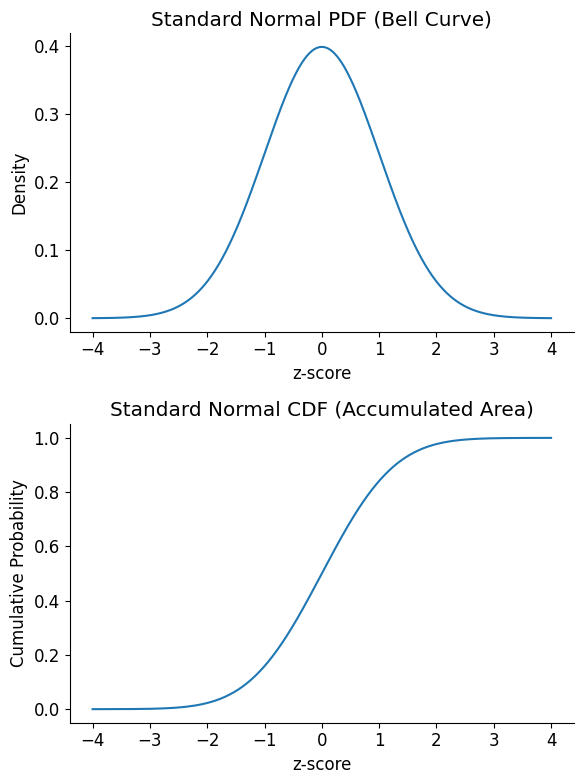

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 400)

pdf = norm.pdf(x)
cdf = norm.cdf(x)

fig, axes = plt.subplots(2, 1, figsize=(6, 8))

# PDF
axes[0].plot(x, pdf)
axes[0].set_title("Standard Normal PDF (Bell Curve)")
axes[0].set_xlabel("z-score")
axes[0].set_ylabel("Density")

# CDF
axes[1].plot(x, cdf)
axes[1].set_title("Standard Normal CDF (Accumulated Area)")
axes[1].set_xlabel("z-score")
axes[1].set_ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()


# What Is a z-Score? (And Why Is It on the x-axis?)

When we plot the **standard normal distribution**, the x-axis is labeled **z-score**.

A **z-score** tells us:

$$
z = \frac{\text{value} - \text{mean}}{\text{standard deviation}}
$$

In words:

> A z-score measures how many standard deviations a value is away from the mean.





## Why Do We Use z-Scores?

Because once we convert something into a z-score:

* The mean becomes **0**
* The standard deviation becomes **1**
* Everything is measured on the same universal scale

This lets us use one single reference distribution:

$$
Z \sim \mathcal{N}(0,1)
$$





## 📊 What Different z-Scores Mean

| z-score | What it means                    | Interpretation         |
| ------- | -------------------------------- | ---------------------- |
| 0       | Exactly at the mean              | No deviation           |
| 1       | 1 standard deviation above mean  | Slightly above average |
| -1      | 1 standard deviation below mean  | Slightly below average |
| 2       | 2 standard deviations above mean | Unusual                |
| -2      | 2 standard deviations below mean | Unusual                |
| 3       | 3 standard deviations above mean | Very rare              |
| -3      | 3 standard deviations below mean | Very rare              |

---

## 🔁 How This Connects to Hypothesis Testing

When we compute:

$$
z = \frac{\text{observed effect}}{\text{standard error}}
$$

We are asking:

> How many “noise units” away from 0 (the null value) is our result?

* The numerator = signal
* The denominator = noise
* The z-score = signal measured in noise units

That’s why the x-axis of the standard normal distribution is labeled **z-score** — it represents distance from the null in standard deviation units.



---
# Part 1 — Population vs Sample: Where Randomness Comes From

There's a real but **unknown** number out there — the true conversion rate, the true average, etc.

You never observe it directly. Instead, you collect **samples** — and every sample gives you a slightly different answer.

| Experiment | Sample conversion rate |
|:----------:|:----------------------:|
| Run 1      | 0.102                 |
| Run 2      | 0.118                 |
| Run 3      | 0.094                 |
| Run 4      | 0.111                 |

Even with **no product change**, the metric moves.

Why? Because every experiment draws a different random set of users.

**Hypothesis testing** exists to answer one question:

> **"Did something actually change… or did I just get lucky noise?"**

### ✏️ Quick check (think before running any code)

**Q1.** If you draw 1,000 samples from the same population, will all the sample means be identical? Why or why not?  

**Q2.** What do you think happens to the variability of the sample mean if sample size grows from 30 to 300?

---
# Part 2 — The Sampling Distribution (The Hidden Distribution)

Imagine repeating the same experiment 10,000 times.

You'd get 10,000 different estimates. The distribution of those estimates is called:

> **The sampling distribution of the estimator**

Key insight: **the metric itself is random** — not because the world is random, but because each sample captures a different slice of it.

Let's simulate this. We'll use an **Exponential** population (highly skewed, definitely *not* Normal) to make the point vivid.

Think: waiting times, time-to-purchase, session durations.

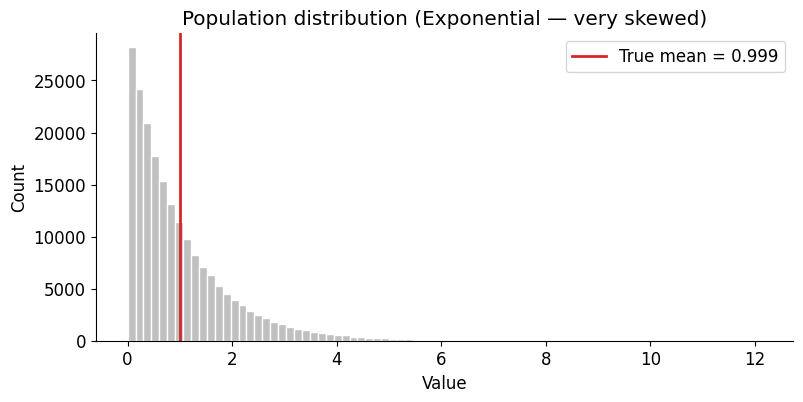

Population mean : 0.9994
Population std  : 0.9986


In [ ]:
# ── Create a skewed population ──────────────────────────
population = np.random.exponential(scale=1.0, size=200_000)

plt.hist(population, bins=80, color="#1a0e0e", edgecolor='white')
plt.axvline(population.mean(), color='#d62728', linewidth=2, label=f'True mean = {population.mean():.3f}')
plt.title('Population distribution (Exponential — very skewed)')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.show()

print(f'Population mean : {population.mean():.4f}')
print(f'Population std  : {population.std():.4f}')

### Building the sampling distribution by hand

We'll draw 5,000 random samples for three different sample sizes and record the mean of each.

**🔮 Prediction (Q3):** As *n* increases, what do you expect to happen to:
- the **shape** of the distribution of sample means?
- the **spread** (width) of that distribution?

In [ ]:
# ── Simulate sampling distributions for n = 5, 30, 300 ─
num_reps = 5000

# n = 5  (tiny sample)
means_n5 = []
for _ in range(num_reps):
    sample = np.random.choice(population, size=5, replace=True)
    means_n5.append(sample.mean()) # Note: I am appending the MEAN OF THE SAMPLE! Not the sample itself.
means_n5 = np.array(means_n5)

# n = 30  (moderate)
means_n30 = []
for _ in range(num_reps):
    sample = np.random.choice(population, size=30, replace=True)
    means_n30.append(sample.mean())  # Note: I am appending the MEAN OF THE SAMPLE! Not the sample itself.
means_n30 = np.array(means_n30)

# n = 300  (large)
means_n300 = []
for _ in range(num_reps):
    sample = np.random.choice(population, size=300, replace=True)
    means_n300.append(sample.mean())  # Note: I am appending the MEAN OF THE SAMPLE! Not the sample itself.
means_n300 = np.array(means_n300)

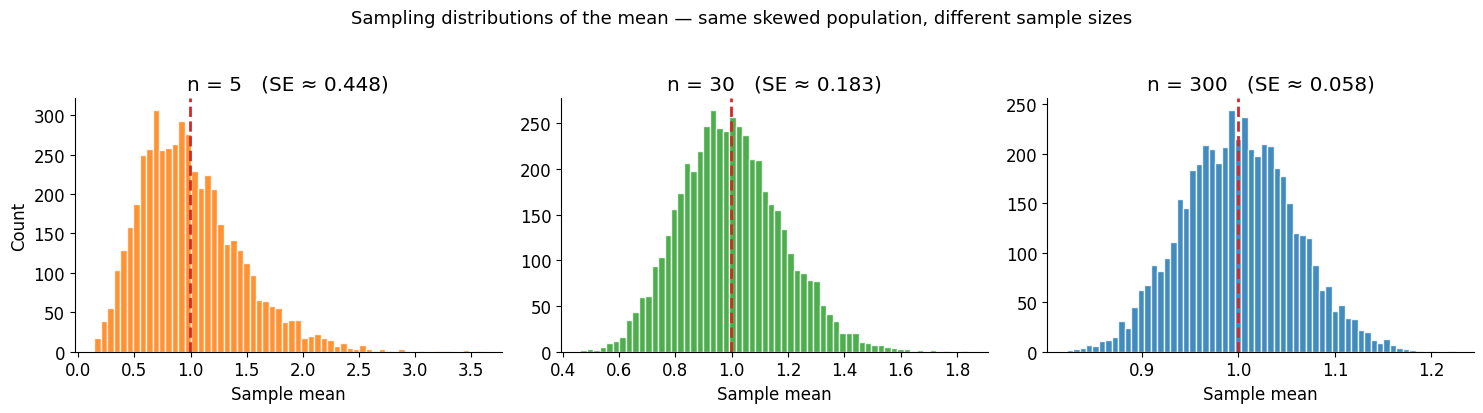

In [35]:
# ── Plot all three sampling distributions ───────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, data, n, color in zip(axes,
                               [means_n5, means_n30, means_n300],
                               [5, 30, 300],
                               ['#ff7f0e', '#2ca02c', '#1f77b4']):
    ax.hist(data, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(population.mean(), color='#d62728', linewidth=2, linestyle='--')
    ax.set_title(f'n = {n}   (SE ≈ {data.std():.3f})')
    ax.set_xlabel('Sample mean')

axes[0].set_ylabel('Count')
fig.suptitle('Sampling distributions of the mean — same skewed population, different sample sizes',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### 🔍 What you should notice

| As *n* increases… | What happens | Why it matters |
|:---|:---|:---|
| **Center** | Stays near the true population mean | The estimator is unbiased |
| **Shape** | Becomes more and more **Normal** | This is the CLT at work |
| **Spread** | Gets **tighter** (less variability) | Larger samples → more precise estimates |

We are not plotting individual exponential values — we are plotting averages of many exponential values. Averages behave differently from individual data points. As we average more values together, skewness gets smoothed out and the distribution of those averages becomes approximately Normal. This is the Central Limit Theorem in action.

### 🧭 Where are we?

Remember our core question: *"If the null hypothesis were true, how surprising is our data?"*

We just built the **sampling distribution** — the distribution of what our statistic *could* look like under repeated sampling. This is the reference distribution we'll eventually compare our observed result against.

| Piece of the puzzle | Status |
|:---|:---|
| Sampling distribution — what our statistic *could* look like | ✅ Just saw this |
| Why that distribution is Normal | ⬜ Next |
| How to measure its spread | ⬜ Coming soon |
| How to use it for a decision | ⬜ Later |

---
# Part 3 — The Central Limit Theorem (Why Tests Work at All)

Look at the three plots above again.

The population was super skewed. But the sampling distribution of the mean became **more and more Normal** as *n* increased.

That's not a coincidence. That's the **Central Limit Theorem**.

> **CLT:** For large enough *n*, the sampling distribution of the sample mean is approximately **Normal** — regardless of the shape of the original population.

In math, even though individual data points come from our skewed population, the *average* behaves like:

$$\bar{x} \;\sim\; \mathcal{N}\!\left(\mu,\; \frac{\sigma^2}{n}\right)$$

⚠️ This does **not** mean the data are Normal. It means the *average* behaves like a Normal variable when *n* is large — even if the individual data points are wildly skewed.

### Why does this matter so much?

| Without the CLT | With the CLT |
|:---|:---|
| We wouldn't know the shape of the sampling distribution | We know it's Normal |
| We couldn't calculate how rare a result is | We can compute exact probabilities |
| Hypothesis testing wouldn't work | It works for almost any type of data |

The CLT is the reason we can do hypothesis testing at all.

---
# Part 4 — Standard Error = Spread of the Sampling Distribution

We know the sampling distribution is approximately Normal (CLT). Now we need to know **how wide** it is.

That width is called the **standard error (SE)**.

Intuition: SE tells you how much the metric "wiggles" purely due to random sampling.

| SE is… | The metric is… | Example |
|:-------|:---------------|:--------|
| Small  | Stable — estimates don't jump around much | Large sample, low variance |
| Large  | Noisy — estimates vary a lot between samples | Small sample, high variance |

The formula for the SE of the sample mean is:

$$SE(\bar{x}) = \frac{\sigma}{\sqrt{n}}$$

Let's check if this formula actually matches our simulation.

In [ ]:
# ── Empirical SE vs Theoretical SE ─────────────────────
pop_std = population.std(ddof=0) # Note the ddof=0 here, since we're treating this as the "population" standard deviation.
                                # If this was a sample, we would use ddof=1 instead.

results = pd.DataFrame({
    'n': [5, 30, 300],
    'Empirical SE (from simulation)': [
        means_n5.std(ddof=1),
        means_n30.std(ddof=1),
        means_n300.std(ddof=1)
    ],
    'Theoretical SE  (σ / √n)': [
        pop_std / np.sqrt(5),
        pop_std / np.sqrt(30),
        pop_std / np.sqrt(300)
    ]
})

results = results.round(4)
results

,n,Empirical SE (from simulation),Theoretical SE (σ / √n)
0,5,0.4476,0.4466
1,30,0.1825,0.1823
2,300,0.0581,0.0577


The empirical and theoretical values line up closely. The formula works.

Notice how SE *shrinks* as *n* grows. Because of the $\sqrt{n}$ in the denominator, you need **4× the sample size to cut SE in half**.

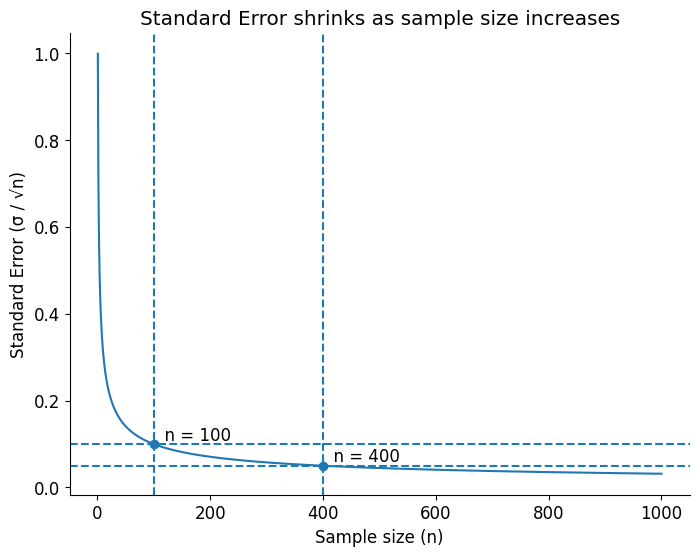

SE at n = 100: 0.0999
SE at n = 400: 0.0499
Ratio (SE_400 / SE_100): 0.50


In [42]:
# ── Visualizing how SE shrinks with n ───────────────────

sigma = pop_std

n_values = np.arange(1, 1001)
se_values = sigma / np.sqrt(n_values)

# Specific points to highlight
n1 = 100
n2 = 400  # 4× larger

se1 = sigma / np.sqrt(n1)
se2 = sigma / np.sqrt(n2)

plt.figure(figsize=(8,6))
plt.plot(n_values, se_values)

# Highlight the two points
plt.scatter([n1, n2], [se1, se2])
plt.axvline(n1, linestyle='--')
plt.axvline(n2, linestyle='--')
plt.axhline(se1, linestyle='--')
plt.axhline(se2, linestyle='--')

plt.title("Standard Error shrinks as sample size increases")
plt.xlabel("Sample size (n)")
plt.ylabel("Standard Error (σ / √n)")

# Annotate the relationship
plt.text(n1, se1, "  n = 100", verticalalignment='bottom')
plt.text(n2, se2, "  n = 400", verticalalignment='bottom')

plt.show()

print(f"SE at n = {n1}: {se1:.4f}")
print(f"SE at n = {n2}: {se2:.4f}")
print(f"Ratio (SE_400 / SE_100): {se2/se1:.2f}")


### 🧭 Where are we?

We now have two critical ingredients:

| Piece of the puzzle | Status |
|:---|:---|
| Sampling distribution — what our statistic *could* look like | ✅ |
| CLT — that distribution is Normal | ✅ |
| Standard error — how wide that distribution is | ✅ Just verified |
| How to use all this for a decision | ⬜ Next! |

Now we have everything we need. We know the shape (Normal) and the width (SE). A hypothesis test simply asks:

> **Is our observed value unusually far from what this distribution predicts?**

---
# Part 5 — Hypothesis Testing: Signal vs Noise

We formalize our question with two competing stories:

| | Meaning |
|:---|:---|
| **Null hypothesis (H₀)** | Nothing changed — any difference is random noise |
| **Alternative hypothesis (H₁)** | Something actually changed |





> We assume H₀ is true, then check: **how surprising is our data?**

### 💡 But why assume H₀ is true?

This trips up a lot of people. We assume "nothing changed" not because we believe it, but because:

| Reason | Explanation |
|:---|:---|
| We need a **baseline story** | Without an assumption, we can't calculate anything |
| H₀ gives us a **reference distribution** | It tells us what random noise looks like |
| We try to **disprove** the default | If the data is too extreme under H₀, we reject it |

Think of it like a scientist's default skepticism: assume the boring explanation until the evidence forces you to accept the interesting one.

The test statistic is just a distance measure:

$$z = \frac{\text{observed difference}}{\text{standard error}} = \frac{\text{signal}}{\text{noise}}$$

| Distance from 0 | Interpretation |
|:-----------------|:---------------|
| < 1 SE | Perfectly normal random noise |
| ~ 2 SE | Unusual — starts to raise eyebrows |
| ≥ 3 SE | Extremely rare under pure chance |

### 💡 Mental model: the courtroom

| Courtroom | Hypothesis Test |
|:----------|:----------------|
| Defendant is assumed innocent | H₀ is assumed true |
| Prosecutor presents evidence | You compute the test statistic |
| "Beyond reasonable doubt" | p-value < significance level (α) |
| Verdict: guilty / not guilty | Reject H₀ / fail to reject H₀ |

You never *prove* innocence. You just ask: is the evidence strong enough to reject the default assumption?

One important note: **α = 0.05 is just a convention — not a magical threshold.** It means we're willing to accept a 5% chance of a false alarm. Some fields use 0.01 or 0.10. The choice should be deliberate, not automatic.

---
# Part 6 — A Concrete A/B Test

You launch a new signup button color and want to know:

> **Does the new button improve conversion rate?**

Our hypotheses:

| | In words | In math |
|:---|:---|:---|
| **H₀** | No improvement — both buttons convert the same | $p_A = p_B$ |
| **H₁** | The new button is better | $p_B > p_A$ |

### Step 1 — Collect data

In [43]:
# ── A/B test data ──────────────────────────────────────
n_A = 1000     # users who saw old button
x_A = 100      # conversions in group A

n_B = 1000     # users who saw new button
x_B = 130      # conversions in group B

pA = x_A / n_A
pB = x_B / n_B
observed_diff = pB - pA

print(f'Conversion A (old) : {pA:.1%}')
print(f'Conversion B (new) : {pB:.1%}')
print(f'Observed difference : {observed_diff:+.1%}')
print()
print('Looks better… but is +3% real or just random noise?')

Conversion A (old) : 10.0%
Conversion B (new) : 13.0%
Observed difference : +3.0%

Looks better… but is +3% real or just random noise?


### Step 2 — What would the difference look like if *nothing* changed?

Before doing any math, let's **simulate** the null world.

If there's truly no difference, both groups share a common conversion rate. We can pool our data to estimate that shared rate, then run thousands of fake experiments where both groups convert at that same rate.

In [48]:
# ── Estimate the shared conversion rate under H₀ ───────
p_pool = (x_A + x_B) / (n_A + n_B)
print(f'Pooled conversion rate (under H₀): {p_pool:.1%}')

Pooled conversion rate (under H₀): 11.5%


### Why do we “pool” the conversion rates?

Under the null hypothesis $H_0: p_A = p_B$, we assume both groups share the same true conversion rate.
If that’s true, the best estimate of that shared rate is:

$$
\hat{p}_{\text{pool}} = \frac{x_A + x_B}{n_A + n_B}
$$

We combine all conversions and all users because, under $H_0$, there is only **one** underlying probability.

This pooled rate is used to calculate the standard error under the null — it represents what the world would look like if there were truly no difference.


### What does `np.random.binomial(n, p)` mean?

The function:

```
np.random.binomial(n, p)
```

simulates the number of **successes** in $n$ independent trials, where each trial has probability $p$ of success.

Mathematically, this is written as:

$$
X \sim \text{Binomial}(n, p)
$$

In our A/B simulation:

* $n_A$ (or $n_B$) = number of users
* $p_{\text{pool}}$ = shared conversion probability under the null hypothesis

So we are simulating:

> "If each of the $n_A$ users converts with probability $p_{\text{pool}}$, how many conversions would we expect just from random chance?"

By repeating this many times, we build the sampling distribution under $H_0$.


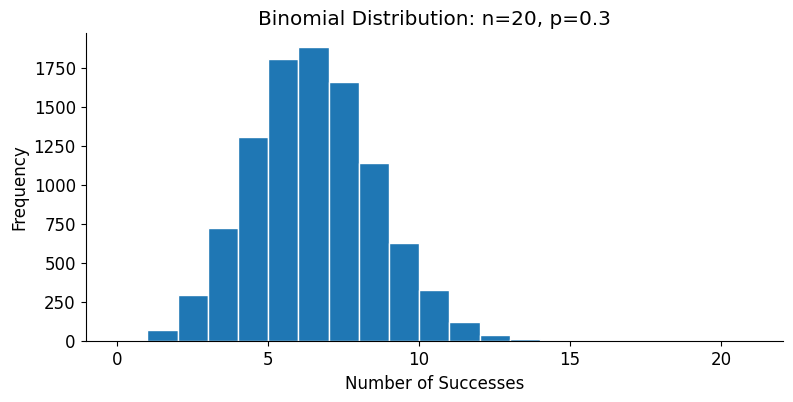

In [51]:
# ── Visualizing a Binomial Distribution ─────────────────

n = 20
p = 0.3
num_simulations = 10000

results = []

for _ in range(num_simulations):
    results.append(np.random.binomial(n, p))

plt.hist(results, bins=range(n+2), edgecolor='white')
plt.title(f'Binomial Distribution: n={n}, p={p}')
plt.xlabel('Number of Successes')
plt.ylabel('Frequency')
plt.show()



Each bar shows how many successes occurred when we ran 20 trials with success probability 0.3.

* Most outcomes are near ( n \times p = 6 )
* Very small or very large numbers of successes are rare
* The distribution is discrete (only whole numbers)

This is exactly what we use in the A/B test simulation — except there, each “trial” is a user converting or not converting.


In [52]:
# ── Simulate 20,000 experiments under H₀ ───────────────
num_reps = 20_000
diffs_under_H0 = []

for _ in range(num_reps):
    # Both groups draw from the SAME conversion rate (p_pool)
    xA_sim = np.random.binomial(n_A, p_pool)
    xB_sim = np.random.binomial(n_B, p_pool)
    pA_sim = xA_sim / n_A
    pB_sim = xB_sim / n_B
    diffs_under_H0.append(pB_sim - pA_sim)

diffs_under_H0 = np.array(diffs_under_H0)

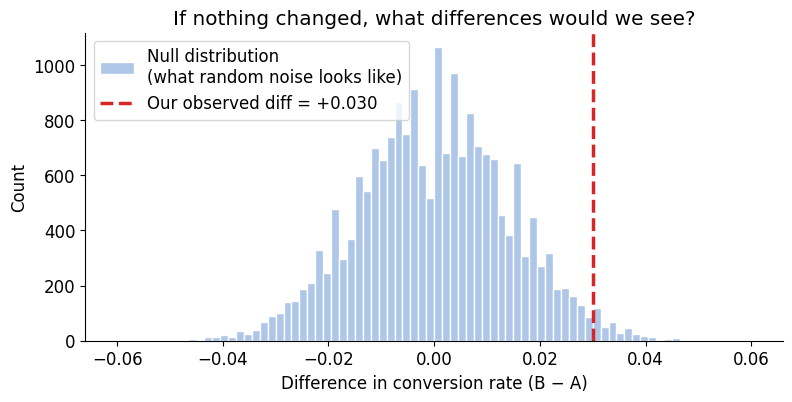

Out of 20,000 fake experiments where nothing changed,
only 2.0% produced a difference as large as what we observed.


In [53]:
# ── Plot the null distribution vs our observed result ──
plt.hist(diffs_under_H0, bins=80, color='#aec7e8', edgecolor='white', label='Null distribution\n(what random noise looks like)')
plt.axvline(observed_diff, color='#d62728', linewidth=2.5, linestyle='--',
            label=f'Our observed diff = {observed_diff:+.3f}')
plt.title('If nothing changed, what differences would we see?')
plt.xlabel('Difference in conversion rate (B − A)')
plt.ylabel('Count')
plt.legend()
plt.show()

# What fraction of simulated experiments had a diff at least as large as ours?
mc_p_value = (diffs_under_H0 >= observed_diff).mean()
print(f'Out of 20,000 fake experiments where nothing changed,')
print(f'only {mc_p_value:.1%} produced a difference as large as what we observed.')

### 🔍 What just happened

- The **histogram** is the sampling distribution of the difference under H₀ — it shows all the differences that random noise *could* produce
- The **red line** is what we actually observed
- The **p-value** is the fraction of simulated experiments that fell to the right of the red line

Our observed difference sits far out in the tail. That's suspicious.

### Step 3 — The z-test: a shortcut for the simulation

We just simulated the null distribution by running 20,000 fake experiments. That works, but it's slow.

The **z-test** is simply a mathematical shortcut for that same simulation — it uses the CLT to compute the null distribution analytically instead of generating it.

Three quick calculations:

**Standard error** — how wide the null distribution is:

$$SE = \sqrt{\hat{p}_{\text{pool}} \,(1 - \hat{p}_{\text{pool}})\left(\frac{1}{n_A} + \frac{1}{n_B}\right)}$$

In [54]:
# ── Standard error under H₀ ────────────────────────────
SE = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
print(f'Standard error: {SE:.4f}')
print(f'(This is the expected "wiggle" in the difference due to random sampling)')

Standard error: 0.0143
(This is the expected "wiggle" in the difference due to random sampling)


**z-score** — how many SEs away from zero our result is:

$$z = \frac{\hat{p}_B - \hat{p}_A}{SE}$$

In [55]:
# ── z-score ────────────────────────────────────────────
z = observed_diff / SE
print(f'z-score: {z:.2f}')
print(f'→ Our observed difference is {z:.1f} standard errors away from zero.')

z-score: 2.10
→ Our observed difference is 2.1 standard errors away from zero.


**p-value** — the probability of getting a z-score this large under the Normal curve:

$$p\text{-value} = P(Z \geq z) \quad \text{where } Z \sim N(0, 1)$$

In [56]:
# ── p-value (one-sided) ────────────────────────────────
p_value = 1 - normal_cdf(z)

print(f'p-value (one-sided): {p_value:.4f}')
print(f'Monte Carlo p-value: {mc_p_value:.4f}')
print()
print('→ The simulation and the formula agree — because the CLT works!')

p-value (one-sided): 0.0177
Monte Carlo p-value: 0.0198

→ The simulation and the formula agree — because the CLT works!


### The full picture — one table

| Quantity | Value | What it means |
|:---------|:------|:--------------|
| Observed diff | +0.030 | The signal — how much B beat A |
| SE | ≈ 0.0143 | The noise — expected random wiggle |
| z-score | ≈ 2.10 | Signal ÷ noise — how extreme the result is |
| p-value | ≈ 0.018 | Probability of seeing ≥ this signal if H₀ is true |

### Step 4 — Make a decision

We compare the p-value to our pre-set significance level α = 0.05.

In [13]:
# ── Decision ───────────────────────────────────────────
alpha = 0.05

print(f'p-value = {p_value:.4f}')
print(f'alpha   = {alpha}')
print()

if p_value < alpha:
    print('✅ Reject H₀ — the improvement is statistically significant.')
else:
    print('❌ Fail to reject H₀ — not enough evidence for a real effect.')

p-value = 0.0177
alpha   = 0.05

✅ Reject H₀ — the improvement is statistically significant.


### ⚠️ Common misunderstanding

| ❌ Wrong interpretation | ✅ Correct interpretation |
|:---|:---|
| "p = 0.018 means there's a 98.2% chance the feature works" | "If the feature did nothing, we'd see a result this extreme only 1.8% of the time" |

The p-value is about the **data under the null** — not about the probability that the hypothesis is true.

### ✏️ Interpretation exercise

**Q5.** Fill in the blank with actual numbers:

> "If the null hypothesis were true (no conversion difference), then seeing a difference at least this large would happen about \_\_\_% of the time due to random sampling alone."

### 🧭 Where are we?

We just did a full hypothesis test — first with simulation, then with math. Let's check back in:

> **If the null hypothesis were true, how surprising is our data? That surprise is the p-value.**

| Piece of the puzzle | How we used it |
|:---|:---|
| Sampling distribution | We simulated 20,000 experiments to see what "random noise" looks like |
| CLT | Told us that distribution is Normal, so we can use the z-test shortcut |
| Standard error | Measured how wide the null distribution is (the expected noise level) |
| z-score | Measured how far our result is from 0, in SE units |
| p-value | Translated that distance into a probability |

---
# Part 7 — Confidence Intervals: The Other Side of the Same Coin

Instead of asking "is the difference zero?", a confidence interval asks:

> **"What range of true differences is consistent with our data?"**

For CIs, we use the *unpooled* SE (each group uses its own conversion rate):

$$SE_{\text{unpooled}} = \sqrt{\frac{\hat{p}_A(1-\hat{p}_A)}{n_A} + \frac{\hat{p}_B(1-\hat{p}_B)}{n_B}}$$

Then:

$$\text{95\% CI} = (\hat{p}_B - \hat{p}_A) \pm 1.96 \times SE_{\text{unpooled}}$$

**Key connection:** If the 95% CI excludes 0, that's equivalent to p < 0.05 in a two-sided test.

In [14]:
# ── Confidence interval ────────────────────────────────
SE_unpooled = np.sqrt(pA * (1 - pA) / n_A + pB * (1 - pB) / n_B)

ci_low  = observed_diff - 1.96 * SE_unpooled
ci_high = observed_diff + 1.96 * SE_unpooled

print(f'Observed difference: {observed_diff:+.3f}')
print(f'95% CI: [{ci_low:+.4f},  {ci_high:+.4f}]')
print()

if ci_low > 0:
    print('→ CI does not include 0 — consistent with a real positive effect.')
else:
    print('→ CI includes 0 — we can\'t rule out no effect.')

Observed difference: +0.030
95% CI: [+0.0021,  +0.0579]

→ CI does not include 0 — consistent with a real positive effect.


### ✏️ Exercise

**Q6.** Does this CI include 0? What does that tell you?  

**Q7.** Is the effect *practically* meaningful? A 3 percentage-point lift sounds good, but what if each conversion is worth $0.01? Always think about business context.

---
# Part 8 — Practice With Real Data (Tips Dataset)

Let's apply everything to a real dataset. We'll ask:

> **Is the average tip percentage different between smokers and non-smokers?**

⚠️ This is **observational** data (not a randomized experiment), so any difference could be due to confounding. But it's great practice for the mechanics.

In [15]:
# ── Load and prepare data ──────────────────────────────
import seaborn as sns

tips = sns.load_dataset('tips')
tips['tip_pct'] = tips['tip'] / tips['total_bill']

tips[['total_bill', 'tip', 'tip_pct', 'smoker']].head(8)

,total_bill,tip,tip_pct,smoker
0,16.99,1.01,0.059447,No
1,10.34,1.66,0.160542,No
2,21.01,3.50,0.166587,No
3,23.68,3.31,0.139780,No
4,24.59,3.61,0.146808,No
5,25.29,4.71,0.186240,No
6,8.77,2.00,0.228050,No
7,26.88,3.12,0.116071,No


In [16]:
# ── Split by group and compute means ───────────────────
smokers    = tips[tips['smoker'] == 'Yes']['tip_pct'].to_numpy()
nonsmokers = tips[tips['smoker'] == 'No']['tip_pct'].to_numpy()

mean_smokers    = smokers.mean()
mean_nonsmokers = nonsmokers.mean()
observed_diff_tips = mean_smokers - mean_nonsmokers

print(f'Smokers     : n = {len(smokers):>3},  mean tip% = {mean_smokers:.4f}')
print(f'Non-smokers : n = {len(nonsmokers):>3},  mean tip% = {mean_nonsmokers:.4f}')
print(f'Difference  : {observed_diff_tips:+.4f}')

Smokers     : n =  93,  mean tip% = 0.1632
Non-smokers : n = 151,  mean tip% = 0.1593
Difference  : +0.0039


**🔮 Prediction (Q8):** Before running the test — do you think this difference is statistically significant? The sample sizes are pretty small.

### z-test for difference in means

Same logic as before, just with means instead of proportions:

$$SE = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}} \qquad\qquad z = \frac{\bar{x}_1 - \bar{x}_2}{SE}$$

In [17]:
# ── z-test (CLT approximation) ─────────────────────────
s1 = smokers.std(ddof=1)
s2 = nonsmokers.std(ddof=1)
n1 = len(smokers)
n2 = len(nonsmokers)

SE_diff = np.sqrt(s1**2 / n1 + s2**2 / n2)
z_diff  = observed_diff_tips / SE_diff

# Two-sided p-value
p_two_sided = 2 * (1 - normal_cdf(abs(z_diff)))

print(f'SE        : {SE_diff:.4f}')
print(f'z-score   : {z_diff:.3f}')
print(f'p-value   : {p_two_sided:.4f}')

SE        : 0.0094
z-score   : 0.411
p-value   : 0.6809


### Reality check: permutation test

Let's also do a **permutation test** — no Normal assumption at all.

If the "smoker" label doesn't matter, we can shuffle it randomly and see what differences we'd get by chance.

In [18]:
# ── Permutation test ───────────────────────────────────
values = tips['tip_pct'].to_numpy()
labels = tips['smoker'].to_numpy()

num_reps = 20_000
perm_diffs = []

for _ in range(num_reps):
    shuffled = np.random.permutation(labels)
    mean_yes = values[shuffled == 'Yes'].mean()
    mean_no  = values[shuffled == 'No'].mean()
    perm_diffs.append(mean_yes - mean_no)

perm_diffs = np.array(perm_diffs)

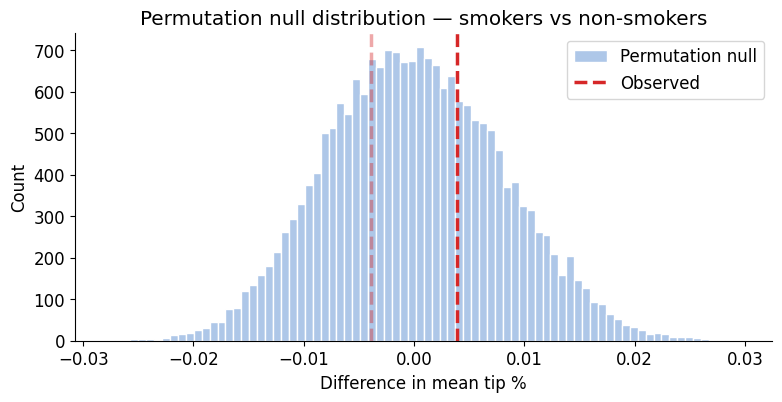

Permutation p-value : 0.6390
z-test p-value      : 0.6809


In [19]:
# ── Plot the permutation null distribution ─────────────
plt.hist(perm_diffs, bins=80, color='#aec7e8', edgecolor='white', label='Permutation null')
plt.axvline( observed_diff_tips, color='#d62728', linewidth=2.5, linestyle='--', label='Observed')
plt.axvline(-observed_diff_tips, color='#d62728', linewidth=2.5, linestyle='--', alpha=0.4)
plt.title('Permutation null distribution — smokers vs non-smokers')
plt.xlabel('Difference in mean tip %')
plt.ylabel('Count')
plt.legend()
plt.show()

# Two-sided permutation p-value
perm_p = (np.abs(perm_diffs) >= abs(observed_diff_tips)).mean()
print(f'Permutation p-value : {perm_p:.4f}')
print(f'z-test p-value      : {p_two_sided:.4f}')

### 🧭 Where are we?

We've now applied hypothesis testing in two settings — a proportion test (A/B) and a means test (tips) — using both math and simulation.

In every case the logic was the same:

> **If the null hypothesis were true, how surprising is our data? That surprise is the p-value.**

| Method | How it builds the null distribution |
|:---|:---|
| z-test | Uses CLT + SE to compute it analytically |
| Simulation | Generates it by running thousands of fake experiments |
| Permutation test | Shuffles labels to generate it |

All three give the same answer — they're just different ways of asking the same question.

---
# Part 9 — Explore: What Happens When You Change *n* or the Effect Size?

This is where intuition really deepens. Try changing the inputs and re-running.

In [20]:
# ── Experiment 1: Same rates, 10× more users ───────────
n_A_big = 10_000
x_A_big = 1000     # still 10% conversion
n_B_big = 10_000
x_B_big = 1300     # still 13% conversion

pA_big = x_A_big / n_A_big
pB_big = x_B_big / n_B_big
diff_big = pB_big - pA_big

p_pool_big = (x_A_big + x_B_big) / (n_A_big + n_B_big)
SE_big = np.sqrt(p_pool_big * (1 - p_pool_big) * (1/n_A_big + 1/n_B_big))
z_big  = diff_big / SE_big
p_val_big = 1 - normal_cdf(z_big)

print('── 10× more users, same 10% vs 13% rates ──')
print(f'SE      : {SE_big:.5f}   (was {SE:.5f})')
print(f'z-score : {z_big:.2f}      (was {z:.2f})')
print(f'p-value : {p_val_big:.6f}  (was {p_value:.4f})')
print()
print('→ More data = smaller SE = bigger z = more certainty.')

── 10× more users, same 10% vs 13% rates ──
SE      : 0.00451   (was 0.01427)
z-score : 6.65      (was 2.10)
p-value : 0.000000  (was 0.0177)

→ More data = smaller SE = bigger z = more certainty.


In [21]:
# ── Experiment 2: Tiny effect, same n ──────────────────
n_A_t = 1000
x_A_t = 100      # 10.0%
n_B_t = 1000
x_B_t = 103      # 10.3%  — tiny difference

pA_t = x_A_t / n_A_t
pB_t = x_B_t / n_B_t
diff_t = pB_t - pA_t

p_pool_t = (x_A_t + x_B_t) / (n_A_t + n_B_t)
SE_t = np.sqrt(p_pool_t * (1 - p_pool_t) * (1/n_A_t + 1/n_B_t))
z_t  = diff_t / SE_t
p_val_t = 1 - normal_cdf(z_t)

print('── Tiny effect (10.0% vs 10.3%), n = 1,000 ──')
print(f'SE      : {SE_t:.4f}')
print(f'z-score : {z_t:.3f}')
print(f'p-value : {p_val_t:.4f}')
print()
print('→ Not significant. The signal is too small relative to the noise.')

── Tiny effect (10.0% vs 10.3%), n = 1,000 ──
SE      : 0.0135
z-score : 0.222
p-value : 0.4121

→ Not significant. The signal is too small relative to the noise.


In [22]:
# ── Experiment 3: Tiny effect + massive n ──────────────
# Can a tiny effect become "significant" with enough data?
n_A_h = 100_000
x_A_h = 10_000     # 10.0%
n_B_h = 100_000
x_B_h = 10_300     # 10.3%  — same tiny difference

pA_h = x_A_h / n_A_h
pB_h = x_B_h / n_B_h
diff_h = pB_h - pA_h

p_pool_h = (x_A_h + x_B_h) / (n_A_h + n_B_h)
SE_h = np.sqrt(p_pool_h * (1 - p_pool_h) * (1/n_A_h + 1/n_B_h))
z_h  = diff_h / SE_h
p_val_h = 1 - normal_cdf(z_h)

print('── Tiny effect (10.0% vs 10.3%), n = 100,000 ──')
print(f'SE      : {SE_h:.5f}')
print(f'z-score : {z_h:.2f}')
print(f'p-value : {p_val_h:.6f}')
print()
print('→ Statistically significant! But is +0.3pp *practically* meaningful?')
print('   This is the difference between statistical and practical significance.')

── Tiny effect (10.0% vs 10.3%), n = 100,000 ──
SE      : 0.00135
z-score : 2.22
p-value : 0.013164

→ Statistically significant! But is +0.3pp *practically* meaningful?
   This is the difference between statistical and practical significance.


### 🔍 Summary of experiments

| Scenario | Rate A | Rate B | n per group | SE | z | p-value | Significant? |
|:---------|:-------|:-------|:------------|:---|:--|:--------|:---|
| Original | 10% | 13% | 1,000 | ≈ 0.014 | ≈ 2.10 | ≈ 0.018 | ✅ Yes |
| 10× users | 10% | 13% | 10,000 | ≈ 0.005 | ≈ 6.63 | ≈ 0.000 | ✅ Very |
| Tiny effect | 10% | 10.3% | 1,000 | ≈ 0.013 | ≈ 0.22 | ≈ 0.413 | ❌ No |
| Tiny + huge n | 10% | 10.3% | 100,000 | ≈ 0.001 | ≈ 2.22 | ≈ 0.013 | ✅ Yes* |

\* Statistically significant, but the effect is likely too small to matter in practice.

**Takeaway:** With enough data, *any* difference becomes statistically significant. That's why you should always ask: **is the effect big enough to matter?**

---
# Part 10 — The Full Conceptual Flow

Here's the real structure of hypothesis testing, stripped down to its essence:

| Step | What happens | Concept |
|:-----|:-------------|:--------|
| 1 | There exists a true parameter (*p*) | Population |
| 2 | Samples create randomness → the estimator varies | Sampling distribution |
| 3 | CLT → the estimator has a Normal sampling distribution | Central Limit Theorem |
| 4 | SE measures the width of that distribution | Standard error |
| 5 | Assume H₀ → difference should be centered at 0 | Null hypothesis |
| 6 | Measure how far the observed value is from 0 | Test statistic (z) |
| 7 | Compute the probability of that happening by chance | p-value |

### The clean mental model

Hypothesis testing uses data to **locate your statistic inside a noise distribution predicted by the null hypothesis**.

$$\text{Test} = \frac{\text{Signal (observed difference)}}{\text{Noise (standard error)}}$$

### One-sentence summary

> Hypothesis testing works because the **Central Limit Theorem** gives us a predictable sampling distribution, the **standard error** measures its spread, and the **p-value** checks whether our observed statistic is unusually far from what randomness alone would produce.